# Szybka teoria
Zakres parametrów:

* $a \in (0, \infty)$
* $m \in (0, \frac{a}{2})$
* $d_1 \in (d_2, \infty)$
* $d_2 \in (0, \infty)$

Założenia, z których korzystamy:

- $a^2 - 4m^2 \geq 0$ z $\Delta$ stanu stacjonarnego
- $d_1 \geq d_2$

# Paremetry z placu Klausmeiera
Teoretyczne wartości, które mogą być ciekawe do porównania. Można je zbadać na koniec

In [3]:
import sys
import os

# Dodanie katalogu głównego repo do ścieżki
sys.path.append(os.path.abspath(".."))

import numpy as np
from pipeline.core import dimensional_to_dimensionless

# FIZYCZNE PARAMETRY
A = [250, 500] # zakres; jednostkka kg * H20 * m^(-2) * rok^(-1)
L = 4 # rok^(-1)
J_tree = 0.002 # (kg * H20)^(-1)
J_grass = 0.003 # (kg * H20)^(-1)
M_tree = 0.18 # rok^(-1)
M_grass = 1.8 # rok^(-1)

# Brakuje: R, DW, DN
# R - pobor wody, czym większy, tym lepiej (zwiększa nam a)
# min dla drzew 2,0736
# min dla trawy 92,16
R_tree = 3 # kg * H20 * m^(-2) * rok^(-1) (kg dry mass)^(-2)
R_grass = 100 # kg * H20 * m^(-2) * rok^(-1) (kg dry mass)^(-2)

# Dw - dyfuzja wody (własne)
Dw = 10**5

# Dn - dyfuzja biomasy (własne)
Dn = 10**2

# Lx z ustaleń
Lx = 60

tryby = ["drzewa", "grass"]
tryb = tryby[1]

if tryb == "drzewa":
    J = J_tree
    M = M_tree
    R = R_tree
else:
    J = J_grass
    M = M_grass
    R = R_grass

a1, m, d1, d2 = dimensional_to_dimensionless(A[0], L, R, Dw, J, M, Dn, Lx)
a2, _, _, _ = dimensional_to_dimensionless(A[1], L, R, Dw, J, M, Dn, Lx)

print([a1, a2], m, d1, d2)

[np.float64(0.9374999999999999), np.float64(1.8749999999999998)] 0.45 6.944444444444445 0.006944444444444444


# Test
W teście skorzystamy z przewidywania istnienia Turinga, więc musimy jedynie dokładnie przetestować $d_1$ i $d_2$

## Badanie parametru $d_1$
stałe $d_2 = 0.02$ i $d_1 \in [1,100]$

In [4]:
d2 = 0.02
d1_vals = np.arange(1, 100, 1) # można zmienic co ile

## Badanie parametru $d_2$
stałe $d_1 = 100$ i $d_2 \in (0,1]$

In [5]:
d1 = 100
d2_vals = np.arange(0.01, 1, 0.01) # można zmienic co ile i odkąd o ile >0

# Jak generować?

Instrukcja użycia:
1. Nie zmieniaj Lx, Ly, Nx, Ny - w tym teście nie testujemy wpływu siatki.
2. W d1_vals lub d2_vals wpisz jedną lub wiele testowanych wartości testowanej dyfuzji. Zakres możesz podzielić na części, aby nie uruchamiać na raz całości, co może zająć godziny, podczas których mogą wyskoczyć błędy.
3. Uruchom komórkę.
4. Parametry zostaną zapisane do pliku .npz.
5. Następnie define_patterns(...) wygeneruje wykresy, dla których musisz oznaczyć wzory.
6. Zapis do cxv jest, aby parametry można było dodatkowo sobie później przeanalizować przy wykorzystaniu np. rstudio.

## Parametr $d_1$

In [ ]:
import sys
import os

# Dodanie katalogu głównego repo do ścieżki
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from pipeline.turing import scan_turing_am, a_m_pairs
from pipeline.patterns import simulate_patterns, plot_patterns
from pipeline.save import save_as_npz, define_patterns, convert_to_csv

# ============================================================
# USTAWIENIA STAŁE SIATKI I ZAKRESÓW SKANOWANIA
# ============================================================
# Parametry siatki ustawione na potrzeby eksperymentu (nie tykać!)
Lx = 60
Ly = Lx
Nx = 100
Ny = Nx

# Zakres testowanych wartości m i a w analizie Turinga. Czym więcej
# tym lepiej, ale też i wolniej.
mvals = np.arange(0.1, 1.51, 0.1)
avals = np.linspace(0.001, 5.0, 250)

# ============================================================
# PARAMETR DYFUZJI TRZYMANY NA STAŁE
# ============================================================
# W tym eksperymencie d2 jest stałe, a testujemy różne wartości d1.
d2 = 0.02

# ============================================================
# PARAMETR DYFUZJI, KTÓRY BĘDZIE SKANOWANY
# ============================================================
# Zakres testu to d1 w [1,100], więc możesz go podzielić, tak że np.
# testujesz 5 wartości [1, 2], a potem 5 z (2, 3] etc.
# Chodzi o to, żeby ostatecznie mieć punkty z całej siatki.

# możesz zmnienić wartości (-, -, co ile chcesz)
d1_vals = np.arange(1, 100, 5)

# ============================================================
# PĘTLA PO TESTOWANYCH WARTOŚCIACH d2
# ============================================================
# Ile chcesz zwróconych macierzy na jedną wartość m?
no_matrixes = 5

# Tutaj nic nie zmieniasz, pętla jest już zrobiona dla dow. układów
all_results = {}
a, m, d1v = [], [], []

for d1 in d1_vals:
    # KROK 1:
    # Skanujemy siatkę parametrów (a, m) dla ustalonych (d1, d2)
    # i sprawdzamy, gdzie pojawia się niestabilność Turinga.
    results = scan_turing_am(d1, d2, m_values=mvals, a_values=avals, k_min=0, k_max=20, n_k=1000)
    all_results[(d1, d2)] = results

    # KROK 2:
    # Z wyników skanu wybieramy reprezentatywne pary (a, m),
    # Możesz zmieniać k to dostaniesz więcej wykresów na jedną m.
    chosen_ones = a_m_pairs(results, mvals, k = no_matrixes)

    # KROK 3:
    # Zamieniamy strukturę zwróconą przez a_m_pairs(...) na zwykłe listy.
    for row in chosen_ones:
        for aval in row["a_band"]:
            a.append(aval)
            m.append(row["m"])
            d1v.append(d1)

# KROK 4:
# Uzupełniamy listy dla dyfuzji.
d1_list = d1v
d2_list = [d2] * len(m)

# ============================================================
# KONTROLA POPRAWNOŚCI DANYCH PRZED ZAPISEM
# ============================================================
if len(a) == len(m) == len(d1_list) == len(d2_list):
    print("Długość wektorów sie zgadza, powinniśmy mieć: ", len(a), " macierzy." )
else:
    raise ValueError("Wektory mają różne długości")

# ============================================================
# ZAPIS PARAMETRÓW DO PLIKU
# ============================================================
# Ten plik będzie wejściem do dalszego etapu.
# Nazwę pliku warto dobierać tak, żeby było wiadomo, co zawiera,
# np.:
#   "patterns_d1_2e-2_scan_d2_1-3",
# gdzie no to kolejny skan.
nazwa_pliku = "patterns_d1_2e-2_scan_d2_"

save_as_npz(nazwa_pliku, a, m, d1_list, d2_list)

# ============================================================
# GENEROWANIE I ETYKIETOWANIE WZORÓW
# ============================================================
define_patterns(nazwa_pliku)
convert_to_csv(nazwa_pliku)

## Parametr $d_2$

In [ ]:
import sys
import os

# Dodanie katalogu głównego repo do ścieżki
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from pipeline.turing import scan_turing_am, a_m_pairs
from pipeline.patterns import simulate_patterns, plot_patterns
from pipeline.save import save_as_npz, define_patterns, convert_to_csv

# ============================================================
# USTAWIENIA STAŁE SIATKI I ZAKRESÓW SKANOWANIA
# ============================================================
# Parametry siatki ustawione na potrzeby eksperymentu (nie tykać!)
Lx = 60
Ly = Lx
Nx = 100
Ny = Nx

# Zakres testowanych wartości m i a w analizie Turinga. Czym więcej
# tym lepiej, ale też i wolniej.
#mvals = np.arange(0.1, 1.51, 0.1)
mvals = [0.45]
avals = np.linspace(0.001, 5.0, 250)

# ============================================================
# PARAMETR DYFUZJI TRZYMANY NA STAŁE
# ============================================================
# W tym eksperymencie d1 jest stałe, a testujemy różne wartości d2.
d1 = 100

# ============================================================
# PARAMETR DYFUZJI, KTÓRY BĘDZIE SKANOWANY
# ============================================================
# Zakres testu to d2 w (0,1], więc możesz sobie to podzielić, tak że np.
# testujesz 5 wartości z (0, 0.01], a potem 5 z (0.01, 0.2] etc.
# Chodzi o to, żeby ostatecznie mieć punkty z całej siatki.

# możesz zmnienić wartości (dow. >0, -, co ile chcesz)
#d2_vals = np.arange(0.01, 1, 0.01)
d2_vals = [0.04]

# ============================================================
# PĘTLA PO TESTOWANYCH WARTOŚCIACH d2
# ============================================================
# Ile chcesz zwroconych macierzy na jedną wartość m?
no_matrixes = 5

# Tutaj nic nie zmieniasz, pętla jest już zrobiona dla dow. układów
all_results = {}
a, m, d2v = [], [], []

for d2 in d2_vals:
    # KROK 1:
    # Skanujemy siatkę parametrów (a, m) dla ustalonych (d1, d2)
    # i sprawdzamy, gdzie pojawia się niestabilność Turinga.
    results = scan_turing_am(d1, d2, m_values=mvals, a_values=avals, k_min=0, k_max=20, n_k=1000)
    all_results[(d1, d2)] = results

    # KROK 2:
    # Z wyników skanu wybieramy reprezentatywne pary (a, m).
    # Możesz zmieniać k to dostaniesz więcej wykresów na jedną m.
    chosen_ones = a_m_pairs(results, mvals, k = no_matrixes)

    # KROK 3:
    # Zamieniamy strukturę zwróconą przez a_m_pairs(...) na zwykłe listy.
    for row in chosen_ones:
        for aval in row["a_band"]:
            a.append(aval)
            m.append(row["m"])
            d2v.append(d2)

# KROK 4:
# Uzupełniamy listy dla dyfuzji.
d2_list = d2v
d1_list = [d1] * len(m)

# ============================================================
# KONTROLA POPRAWNOŚCI DANYCH PRZED ZAPISEM
# ============================================================
if len(a) == len(m) == len(d1_list) == len(d2_list):
    print("Długość wektorów sie zgadza, powinniśmy mieć: ", len(a), " macierzy." )
else:
    raise ValueError("Wektory mają różne długości")

# ============================================================
# ZAPIS PARAMETRÓW DO PLIKU
# ============================================================
# Ten plik będzie wejściem do dalszego etapu.
# Nazdwę pliku warto dobierać tak, żeby było wiadomo, co zawiera,
# np.:
#   "patterns_d1_100_scan_d2_0.01-0.005",
# gdzie no to kolejny skan.
nazwa_pliku = "patterns_d1_100_scan_d2_delete"
save_as_npz(nazwa_pliku, a, m, d1_list, d2_list)

# ============================================================
# GENEROWANIE I ETYKIETOWANIE WZORÓW
# ============================================================
define_patterns(nazwa_pliku)
convert_to_csv(nazwa_pliku)

# PREZENTACJA

Długość wektorów sie zgadza, powinniśmy mieć:  5  macierzy.


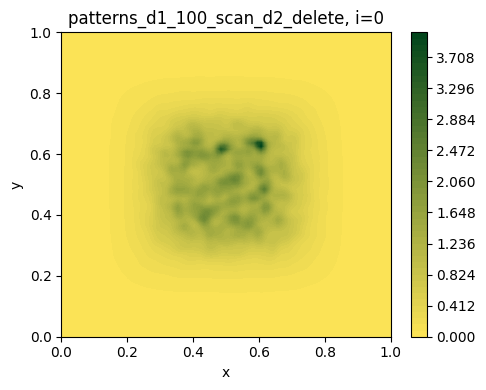

0. nothing, 1. spots, 2. stripes, 3. labyrinths, 4. gaps, 5. something else (d=delete)(q=quit):  d


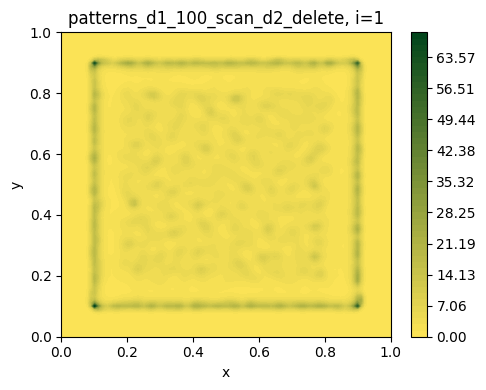

0. nothing, 1. spots, 2. stripes, 3. labyrinths, 4. gaps, 5. something else (d=delete)(q=quit):  d


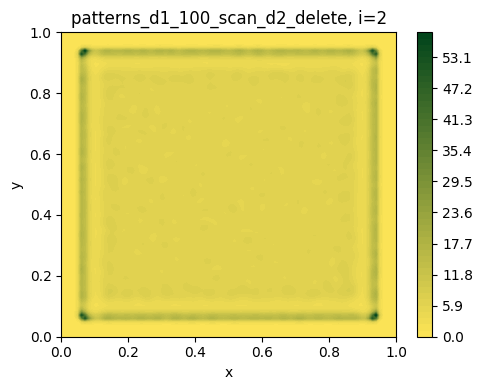

0. nothing, 1. spots, 2. stripes, 3. labyrinths, 4. gaps, 5. something else (d=delete)(q=quit):  d


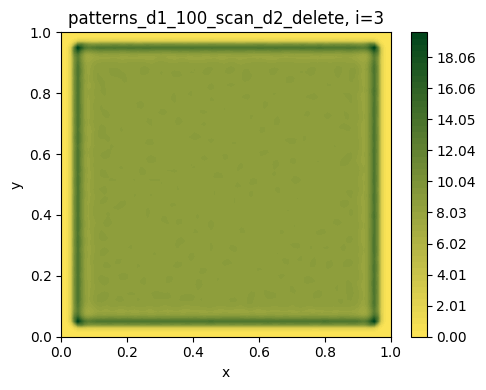

0. nothing, 1. spots, 2. stripes, 3. labyrinths, 4. gaps, 5. something else (d=delete)(q=quit):  d


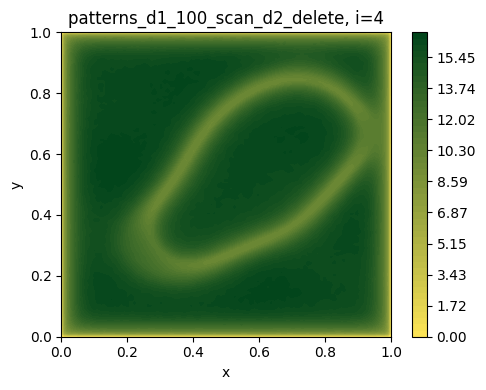

0. nothing, 1. spots, 2. stripes, 3. labyrinths, 4. gaps, 5. something else (d=delete)(q=quit):  d


Deleted 5/5 matrices.
End of file. Patterns are defined on 0/0 matrices.
File saved to: wykresy_etykiety\patterns_d1_100_scan_d2_delete.npz
CSV saved to: wykresy_etykiety_csv\patterns_d1_100_scan_d2_delete.csv


,a,m,d1,d2,pattern


In [1]:
import sys
import os

# Dodanie katalogu głównego repo do ścieżki
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from pipeline.turing import scan_turing_am, a_m_pairs
from pipeline.patterns import simulate_patterns, plot_patterns
from pipeline.save import save_as_npz, define_patterns, convert_to_csv

# ============================================================
# USTAWIENIA STAŁE SIATKI I ZAKRESÓW SKANOWANIA
# ============================================================
# Parametry siatki ustawione na potrzeby eksperymentu (nie tykać!)
Lx = 60
Ly = Lx
Nx = 100
Ny = Nx

# Zakres testowanych wartości m i a w analizie Turinga. Czym więcej
# tym lepiej, ale też i wolniej.
#mvals = np.arange(0.1, 1.51, 0.1)
mvals = [0.45]
avals = np.linspace(0.001, 5.0, 250)

# ============================================================
# PARAMETR DYFUZJI TRZYMANY NA STAŁE
# ============================================================
# W tym eksperymencie d1 jest stałe, a testujemy różne wartości d2.
d1 = 100

# ============================================================
# PARAMETR DYFUZJI, KTÓRY BĘDZIE SKANOWANY
# ============================================================
# Zakres testu to d2 w (0,1], więc możesz sobie to podzielić, tak że np.
# testujesz 5 wartości z (0, 0.01], a potem 5 z (0.01, 0.2] etc.
# Chodzi o to, żeby ostatecznie mieć punkty z całej siatki.

# możesz zmnienić wartości (dow. >0, -, co ile chcesz)
#d2_vals = np.arange(0.01, 1, 0.01)
d2_vals = [0.04]

# ============================================================
# PĘTLA PO TESTOWANYCH WARTOŚCIACH d2
# ============================================================
# Ile chcesz zwroconych macierzy na jedną wartość m?
no_matrixes = 5

# Tutaj nic nie zmieniasz, pętla jest już zrobiona dla dow.
# układów
all_results = {}
a, m, d2v = [], [], []

for d2 in d2_vals:
    # KROK 1:
    # Skanujemy siatkę parametrów (a, m) dla ustalonych (d1, d2)
    # i sprawdzamy, gdzie pojawia się niestabilność Turinga.
    results = scan_turing_am(d1, d2, m_values=mvals, a_values=avals, k_min=0, k_max=20, n_k=1000)
    all_results[(d1, d2)] = results

    # KROK 2:
    # Z wyników skanu wybieramy reprezentatywne pary (a, m).
    # Możesz zmieniać k to dostaniesz więcej wykresów na jedną m.
    chosen_ones = a_m_pairs(results, mvals, k = no_matrixes)

    # KROK 3:
    # Zamieniamy strukturę zwróconą przez a_m_pairs(...) na zwykłe listy.
    for row in chosen_ones:
        for aval in row["a_band"]:
            a.append(aval)
            m.append(row["m"])
            d2v.append(d2)

# KROK 4:
# Uzupełniamy listy dla dyfuzji.
d2_list = d2v
d1_list = [d1] * len(m)

# ============================================================
# KONTROLA POPRAWNOŚCI DANYCH PRZED ZAPISEM
# ============================================================
if len(a) == len(m) == len(d1_list) == len(d2_list):
    print("Długość wektorów sie zgadza, powinniśmy mieć: ", len(a), " macierzy." )
else:
    raise ValueError("Wektory mają różne długości")

# ============================================================
# ZAPIS PARAMETRÓW DO PLIKU
# ============================================================
# Ten plik będzie wejściem do dalszego etapu.
# Nazdwę pliku warto dobierać tak, żeby było wiadomo, co zawiera,
# np.:
#   "patterns_d1_100_scan_d2_0.01-0.005",
# gdzie no to kolejny skan.
nazwa_pliku = "patterns_d1_100_scan_d2_delete"
save_as_npz(nazwa_pliku, a, m, d1_list, d2_list)

# ============================================================
# GENEROWANIE I ETYKIETOWANIE WZORÓW
# ============================================================
define_patterns(nazwa_pliku)
convert_to_csv(nazwa_pliku)